<a href="https://colab.research.google.com/github/jamesiswanto/Numerical-Differentiation-Methods-for-Rocket-Velocity-Analysis/blob/development/Numerical_Differentiation_Methods_for_Rocket_Velocity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log

In [2]:
def velocity_function(t):
    """
    Calculate velocity at time t using the formula from the document
    v(t) = 2000 * ln[14x10^4 / (14x10^4 - 2100t)] - 9.8t

    Args:
        t (float): Time in seconds

    Returns:
        float: Velocity at time t in m/s
    """
    # Constants from the problem
    m0 = 14 * 10**4  # Initial mass
    q = 2100         # Rate of mass loss
    g = 9.8          # Gravity acceleration

    # Calculate velocity using the given formula
    try:
        velocity = 2000 * np.log(m0 / (m0 - q*t)) - g * t
        return velocity
    except (ValueError, ZeroDivisionError):
        print(f"Error calculating velocity at t = {t}, likely because (m0 - q*t) <= 0")
        return None

In [3]:
def forward_difference_derivative(func, t, delta_t=1.0):
    """
    Calculate derivative using Forward Difference method (FDD)
    a(t) ≈ [v(t+Δt) - v(t)] / Δt

    Args:
        func (function): Function to differentiate
        t (float): Point at which to calculate derivative
        delta_t (float): Step size

    Returns:
        float: Approximated derivative
    """
    v_t = func(t)
    v_t_plus = func(t + delta_t)

    # If any velocity calculation failed, return None
    if v_t is None or v_t_plus is None:
        return None

    return (v_t_plus - v_t) / delta_t

In [4]:
def backward_difference_derivative(func, t, delta_t=1.0):
    """
    Calculate derivative using Backward Difference method (BDD)
    a(t) ≈ [v(t) - v(t-Δt)] / Δt

    Args:
        func (function): Function to differentiate
        t (float): Point at which to calculate derivative
        delta_t (float): Step size

    Returns:
        float: Approximated derivative
    """
    v_t = func(t)
    v_t_minus = func(t - delta_t)

    # If any velocity calculation failed, return None
    if v_t is None or v_t_minus is None:
        return None

    return (v_t - v_t_minus) / delta_t

In [5]:
def central_difference_derivative(func, t, delta_t=1.0):
    """
    Calculate derivative using Central Difference method (CDD)
    a(t) ≈ [v(t+Δt) - v(t-Δt)] / (2*Δt)

    Args:
        func (function): Function to differentiate
        t (float): Point at which to calculate derivative
        delta_t (float): Step size

    Returns:
        float: Approximated derivative
    """
    v_t_plus = func(t + delta_t)
    v_t_minus = func(t - delta_t)

    # If any velocity calculation failed, return None
    if v_t_plus is None or v_t_minus is None:
        return None

    return (v_t_plus - v_t_minus) / (2 * delta_t)

In [6]:
def compare_methods(t=16, delta_t=1.0):
    """
    Compare all three differentiation methods at a specific time point

    Args:
        t (float): Time point to calculate acceleration
        delta_t (float): Step size for differentiation

    Returns:
        dict: Results from each method
    """
    # Calculate velocities at required time points
    v_t_minus = velocity_function(t - delta_t)
    v_t = velocity_function(t)
    v_t_plus = velocity_function(t + delta_t)

    print(f"Velocity at t-Δt = {t-delta_t}s: {v_t_minus:.4f} m/s")
    print(f"Velocity at t = {t}s: {v_t:.4f} m/s")
    print(f"Velocity at t+Δt = {t+delta_t}s: {v_t_plus:.4f} m/s")
    print("-" * 50)

    # Calculate acceleration using each method
    fdd = forward_difference_derivative(velocity_function, t, delta_t)
    bdd = backward_difference_derivative(velocity_function, t, delta_t)
    cdd = central_difference_derivative(velocity_function, t, delta_t)

    # Print results
    print(f"Forward Difference (FDD) at t = {t}s: {fdd:.4f} m/s²")
    print(f"Backward Difference (BDD) at t = {t}s: {bdd:.4f} m/s²")
    print(f"Central Difference (CDD) at t = {t}s: {cdd:.4f} m/s²")

    return {
        "FDD": fdd,
        "BDD": bdd,
        "CDD": cdd,
        "v_t_minus": v_t_minus,
        "v_t": v_t,
        "v_t_plus": v_t_plus
    }

In [7]:
def plot_velocity_and_acceleration(t_range):
    """
    Plot velocity and acceleration calculated by all three methods
    over a range of time values

    Args:
        t_range (list or array): Range of time values to plot
    """
    # Calculate velocities
    velocities = [velocity_function(t) for t in t_range]

    # Calculate accelerations using all three methods
    fdd_values = [forward_difference_derivative(velocity_function, t) for t in t_range]
    bdd_values = [backward_difference_derivative(velocity_function, t) for t in t_range]
    cdd_values = [central_difference_derivative(velocity_function, t) for t in t_range]

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

    # Plot velocity
    ax1.plot(t_range, velocities, 'b-', linewidth=2)
    ax1.set_title('Velocity vs. Time')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Velocity (m/s)')
    ax1.grid(True)

    # Plot accelerations
    ax2.plot(t_range, fdd_values, 'r-', label='Forward Difference (FDD)')
    ax2.plot(t_range, bdd_values, 'g-', label='Backward Difference (BDD)')
    ax2.plot(t_range, cdd_values, 'b-', label='Central Difference (CDD)')
    ax2.set_title('Acceleration vs. Time')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Acceleration (m/s²)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [8]:
def main():
    """
    Main function to run the program and display results
    """
    print("Numerical Differentiation Methods for Rocket Acceleration")
    print("=" * 60)

    # Compare methods at t = 16s (as in the example)
    print("\nComparing methods at t = 16s:")
    results = compare_methods(t=16, delta_t=1.0)

    # Plot velocity and acceleration over time range
    t_range = np.linspace(0, 60, 200)  # Time range from 0 to 60 seconds

    print("\nGenerating plots for velocity and acceleration...")
    plot_velocity_and_acceleration(t_range)

    print("\nProgram completed successfully.")

Numerical Differentiation Methods for Rocket Acceleration

Comparing methods at t = 16s:
Velocity at t-Δt = 15.0s: 362.7845 m/s
Velocity at t = 16s: 392.0737 m/s
Velocity at t+Δt = 17.0s: 422.1421 m/s
--------------------------------------------------
Forward Difference (FDD) at t = 16s: 30.0684 m/s²
Backward Difference (BDD) at t = 16s: 29.2892 m/s²
Central Difference (CDD) at t = 16s: 29.6788 m/s²

Generating plots for velocity and acceleration...


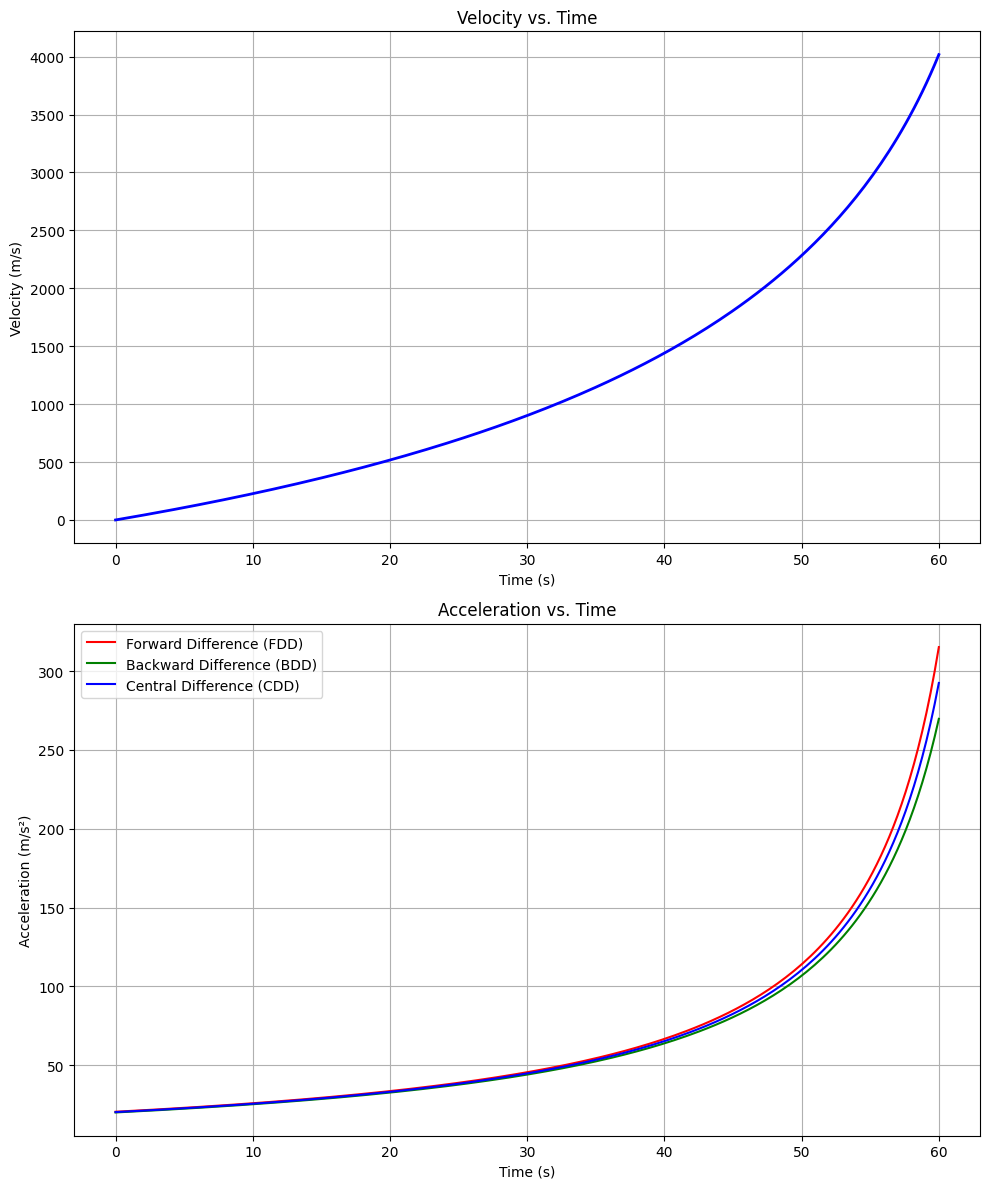


Program completed successfully.


In [9]:
if __name__ == "__main__":
    main()